# Sistema Fuzzy Mamdani para Controle de Ventilação em Ambientes Fechados

Este notebook implementa um sistema fuzzy Mamdani para auxiliar no controle da ventilação de ambientes fechados, promovendo conforto térmico e eficiência energética. O sistema utiliza como entradas: temperatura interna (°C), umidade relativa (%) e número de pessoas.

## 1. Definição dos Universos de Discurso e Funções de Pertinência

Cada variável de entrada e saída é particionada em três conjuntos fuzzy com funções de pertinência triangulares.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Função de pertinência triangular
def trimf(x, a, b, c):
    return np.maximum(np.minimum((x-a)/(b-a+1e-9), (c-x)/(c-b+1e-9)), 0)

# Universos de discurso
temp_univ = np.arange(15, 36, 1)
umid_univ = np.arange(20, 101, 1)
pess_univ = np.arange(0, 21, 1)
vent_univ = np.arange(0, 11, 0.1)

# Funções de pertinência
def temp_baixa(x): return trimf(x, 15, 15, 22)
def temp_media(x): return trimf(x, 18, 24, 30)
def temp_alta(x):  return trimf(x, 25, 35, 35)

def umid_baixa(x): return trimf(x, 20, 20, 45)
def umid_media(x): return trimf(x, 35, 60, 85)
def umid_alta(x):  return trimf(x, 70, 100, 100)

def pess_poucas(x):   return trimf(x, 0, 0, 7)
def pess_moderado(x): return trimf(x, 3, 10, 17)
def pess_muitas(x):   return trimf(x, 12, 20, 20)

def vent_fraca(x):    return trimf(x, 0, 0, 4)
def vent_moderada(x): return trimf(x, 2, 5, 8)
def vent_forte(x):    return trimf(x, 6, 10, 10)

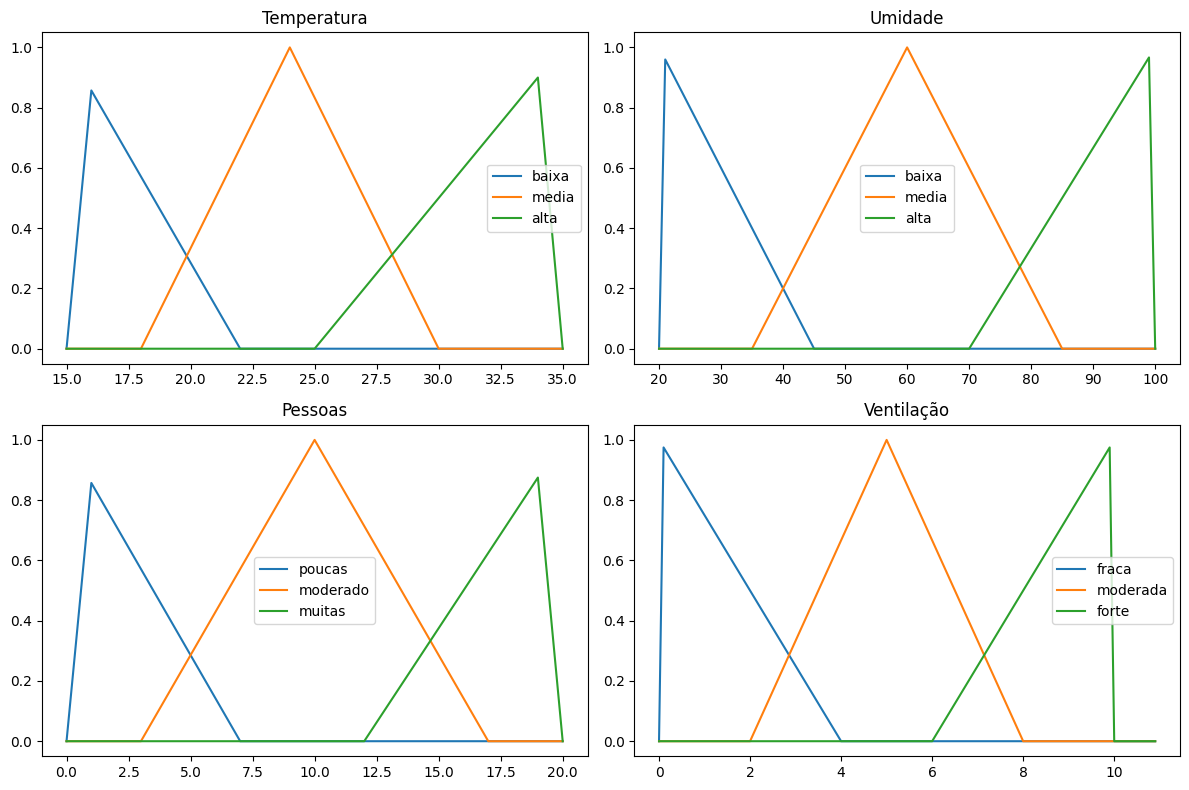

In [2]:
# Visualização das funções de pertinência
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.plot(temp_univ, temp_baixa(temp_univ), label='baixa')
plt.plot(temp_univ, temp_media(temp_univ), label='media')
plt.plot(temp_univ, temp_alta(temp_univ), label='alta')
plt.title('Temperatura')
plt.legend()

plt.subplot(2,2,2)
plt.plot(umid_univ, umid_baixa(umid_univ), label='baixa')
plt.plot(umid_univ, umid_media(umid_univ), label='media')
plt.plot(umid_univ, umid_alta(umid_univ), label='alta')
plt.title('Umidade')
plt.legend()

plt.subplot(2,2,3)
plt.plot(pess_univ, pess_poucas(pess_univ), label='poucas')
plt.plot(pess_univ, pess_moderado(pess_univ), label='moderado')
plt.plot(pess_univ, pess_muitas(pess_univ), label='muitas')
plt.title('Pessoas')
plt.legend()

plt.subplot(2,2,4)
plt.plot(vent_univ, vent_fraca(vent_univ), label='fraca')
plt.plot(vent_univ, vent_moderada(vent_univ), label='moderada')
plt.plot(vent_univ, vent_forte(vent_univ), label='forte')
plt.title('Ventilação')
plt.legend()
plt.tight_layout()
if not os.path.exists("img"):
    os.makedirs("img")
plt.savefig("img/funcoes_pertinencia_mamdani2.png")
plt.show()

## 2. Base de Regras Fuzzy

As regras foram construídas com base em conhecimento comum sobre conforto térmico:

In [3]:
def regras_fuzzy(mu_temp, mu_umid, mu_pess, operador='padrao'):
    regras = []
    min_op = min
    max_op = max
    if operador == 'and_produto':
        min_op = lambda a, b: a * b
    if operador == 'or_soma':
        max_op = lambda a, b, c: min(a + b + c, 1)
    regras.append(('forte', max_op(mu_temp['alta'], mu_umid['alta'], mu_pess['muitas']), 'R1'))
    regras.append(('moderada', min_op(mu_temp['media'], min_op(mu_umid['media'], mu_pess['moderado'])), 'R2'))
    regras.append(('fraca', min_op(mu_temp['baixa'], min_op(mu_umid['baixa'], mu_pess['poucas'])), 'R3'))
    regras.append(('moderada', min_op(mu_temp['alta'], mu_umid['baixa']), 'R4'))
    regras.append(('forte', min_op(mu_temp['media'], mu_pess['muitas']), 'R5'))
    regras.append(('moderada', min_op(mu_umid['alta'], mu_pess['poucas']), 'R6'))
    regras.append(('fraca', max_op(mu_temp['baixa'], mu_umid['baixa'], 0), 'R7'))
    regras.append(('moderada', min_op(mu_pess['moderado'], mu_umid['media']), 'R8'))
    regras.append(('forte', min_op(mu_temp['media'], mu_umid['alta']), 'R9'))
    return regras

## 3. Fuzzificação das Entradas

In [4]:
def fuzzificar(entrada):
    mu_temp = {
        'baixa': temp_baixa(entrada['temperatura']),
        'media': temp_media(entrada['temperatura']),
        'alta':  temp_alta(entrada['temperatura'])
    }
    mu_umid = {
        'baixa': umid_baixa(entrada['umidade']),
        'media': umid_media(entrada['umidade']),
        'alta':  umid_alta(entrada['umidade'])
    }
    mu_pess = {
        'poucas':   pess_poucas(entrada['pessoas']),
        'moderado': pess_moderado(entrada['pessoas']),
        'muitas':   pess_muitas(entrada['pessoas'])
    }
    return mu_temp, mu_umid, mu_pess

## 4. Inferência Mamdani e Agregação

In [5]:
def mamdani(entrada, operador='padrao'):
    mu_temp, mu_umid, mu_pess = fuzzificar(entrada)
    regras = regras_fuzzy(mu_temp, mu_umid, mu_pess, operador)
    saida_vent = np.zeros_like(vent_univ)
    regras_ativadas = []
    for nome, firing, reg in regras:
        if firing > 0:
            regras_ativadas.append((reg, nome, firing))
            if nome == 'fraca':
                saida_vent = np.maximum(saida_vent, np.minimum(firing, vent_fraca(vent_univ)))
            elif nome == 'moderada':
                saida_vent = np.maximum(saida_vent, np.minimum(firing, vent_moderada(vent_univ)))
            elif nome == 'forte':
                saida_vent = np.maximum(saida_vent, np.minimum(firing, vent_forte(vent_univ)))
    return saida_vent, regras_ativadas, mu_temp, mu_umid, mu_pess

## 5. Técnicas de Defuzzificação

In [6]:
def defuzz_centroide(x, mf):
    if np.sum(mf) == 0:
        return 0
    return np.sum(x * mf) / np.sum(mf)

def defuzz_media_maximo(x, mf):
    maxv = np.max(mf)
    if maxv == 0:
        return 0
    return np.mean(x[mf == maxv])

def defuzz_bissetriz(x, mf):
    area_total = np.sum(mf)
    if area_total == 0:
        return 0
    soma = 0
    for i in range(len(x)):
        soma += mf[i]
        if soma >= area_total/2:
            return x[i]
    return x[-1]

## 6. Simulações: 5 Cenários, Operadores e Defuzzificação

In [7]:
cenarios = [
    {'temperatura': 28, 'umidade': 80, 'pessoas': 15},  # Cenário 1
    {'temperatura': 22, 'umidade': 50, 'pessoas': 5},   # Cenário 2
    {'temperatura': 18, 'umidade': 30, 'pessoas': 2},   # Cenário 3
    {'temperatura': 32, 'umidade': 60, 'pessoas': 10},  # Cenário 4
    {'temperatura': 25, 'umidade': 90, 'pessoas': 8},   # Cenário 5
]

operadores = ['padrao', 'and_produto', 'or_soma']
defuzzificadores = [
    ('Centroide', defuzz_centroide),
    ('Média do Máximo', defuzz_media_maximo),
    ('Bissetriz', defuzz_bissetriz)
]

for op in operadores:
    print(f"\n--- Operador lógico: {op} ---")
    for i, c in enumerate(cenarios):
        saida_vent, regras_ativadas, _, _, _ = mamdani(c, operador=op)
        resultados = []
        for nome, func in defuzzificadores:
            val = func(vent_univ, saida_vent)
            resultados.append(f"{nome}: {val:.2f}")
        print(f"Cenário {i+1}: Entrada={c} | " + " | ".join(resultados))


--- Operador lógico: padrao ---
Cenário 1: Entrada={'temperatura': 28, 'umidade': 80, 'pessoas': 15} | Centroide: 6.71 | Média do Máximo: 8.75 | Bissetriz: 7.20
Cenário 2: Entrada={'temperatura': 22, 'umidade': 50, 'pessoas': 5} | Centroide: 5.00 | Média do Máximo: 5.00 | Bissetriz: 5.00
Cenário 3: Entrada={'temperatura': 18, 'umidade': 30, 'pessoas': 2} | Centroide: 1.51 | Média do Máximo: 0.80 | Bissetriz: 1.40
Cenário 4: Entrada={'temperatura': 32, 'umidade': 60, 'pessoas': 10} | Centroide: 6.28 | Média do Máximo: 5.00 | Bissetriz: 5.90
Cenário 5: Entrada={'temperatura': 25, 'umidade': 90, 'pessoas': 8} | Centroide: 8.53 | Média do Máximo: 9.30 | Bissetriz: 8.60

--- Operador lógico: and_produto ---
Cenário 1: Entrada={'temperatura': 28, 'umidade': 80, 'pessoas': 15} | Centroide: 7.64 | Média do Máximo: 8.75 | Bissetriz: 8.00
Cenário 2: Entrada={'temperatura': 22, 'umidade': 50, 'pessoas': 5} | Centroide: 5.00 | Média do Máximo: 5.00 | Bissetriz: 5.00
Cenário 3: Entrada={'temperatu

## 7. Visualização: Superfície Fuzzy (Temperatura x Umidade, Pessoas=10)

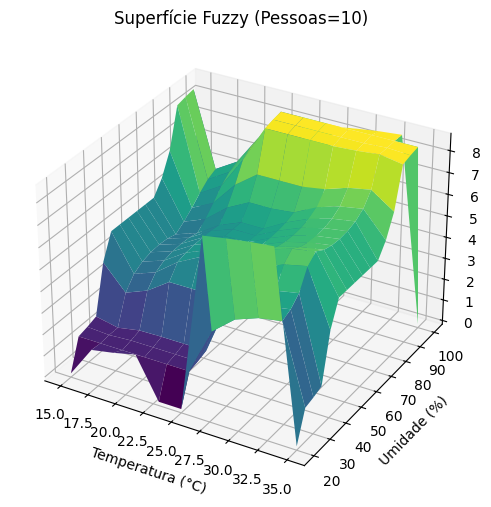

In [8]:
x = np.arange(15, 36, 2)
y = np.arange(20, 101, 5)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X, dtype=float)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        entrada = {'temperatura': X[i, j], 'umidade': Y[i, j], 'pessoas': 10}
        saida_vent, _, _, _, _ = mamdani(entrada)
        Z[i, j] = defuzz_centroide(vent_univ, saida_vent)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Umidade (%)')
ax.set_zlabel('Ventilação')
plt.title('Superfície Fuzzy (Pessoas=10)')
plt.savefig("img/superficie_fuzzy_pessoas10_mamdani2.png")
plt.show()

## 8. Processo Detalhado: Cenário 1

Demonstração completa do processo fuzzy para o cenário 1.

In [9]:
entrada = cenarios[0]
saida_vent, regras_ativadas, mu_temp, mu_umid, mu_pess = mamdani(entrada)
print("Fuzzificação (graus de pertinência):")
print("  Temperatura:", mu_temp)
print("  Umidade:", mu_umid)
print("  Pessoas:", mu_pess)
print("\nRegras ativadas e firing strength:")
for reg, nome, firing in regras_ativadas:
    print(f"  {reg}: {nome} (nível={firing:.3f})")

centroide = defuzz_centroide(vent_univ, saida_vent)
media_max = defuzz_media_maximo(vent_univ, saida_vent)
bissetriz = defuzz_bissetriz(vent_univ, saida_vent)
print(f"\nDefuzzificação:")
print(f"  Centroide: {centroide:.2f}")
print(f"  Média do Máximo: {media_max:.2f}")
print(f"  Bissetriz: {bissetriz:.2f}")

Fuzzificação (graus de pertinência):
  Temperatura: {'baixa': np.float64(0.0), 'media': np.float64(0.33333333327777775), 'alta': np.float64(0.29999999997)}
  Umidade: {'baixa': np.float64(0.0), 'media': np.float64(0.199999999992), 'alta': np.float64(0.3333333333222222)}
  Pessoas: {'poucas': np.float64(0.0), 'moderado': np.float64(0.2857142856734694), 'muitas': np.float64(0.374999999953125)}

Regras ativadas e firing strength:
  R1: forte (nível=0.375)
  R2: moderada (nível=0.200)
  R5: forte (nível=0.333)
  R8: moderada (nível=0.200)
  R9: forte (nível=0.333)

Defuzzificação:
  Centroide: 6.71
  Média do Máximo: 8.75
  Bissetriz: 7.20


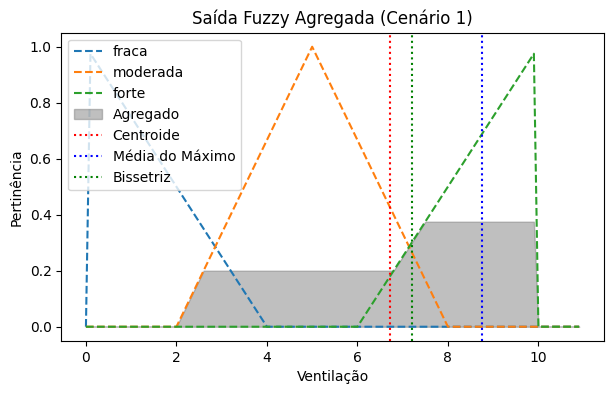

In [10]:
# Visualização da saída fuzzy agregada do cenário 1
plt.figure(figsize=(7,4))
plt.plot(vent_univ, vent_fraca(vent_univ), '--', label='fraca')
plt.plot(vent_univ, vent_moderada(vent_univ), '--', label='moderada')
plt.plot(vent_univ, vent_forte(vent_univ), '--', label='forte')
plt.fill_between(vent_univ, 0, saida_vent, color='gray', alpha=0.5, label='Agregado')
plt.axvline(centroide, color='red', linestyle=':', label='Centroide')
plt.axvline(media_max, color='blue', linestyle=':', label='Média do Máximo')
plt.axvline(bissetriz, color='green', linestyle=':', label='Bissetriz')
plt.title('Saída Fuzzy Agregada (Cenário 1)')
plt.xlabel('Ventilação')
plt.ylabel('Pertinência')
plt.legend()
plt.savefig("img/saida_fuzzy_cenario1_mamdani2.png")
plt.show()

## 9. Interpretação Qualitativa

A intensidade de ventilação sugerida para o cenário 1 é:

In [11]:
if centroide < 4:
    nivel = "fraca"
elif centroide < 7:
    nivel = "moderada"
else:
    nivel = "forte"
print(f"A intensidade de ventilação sugerida é '{nivel.upper()}' ({centroide:.2f}), adequada ao cenário de temperatura, umidade e ocupação elevadas.")

A intensidade de ventilação sugerida é 'MODERADA' (6.71), adequada ao cenário de temperatura, umidade e ocupação elevadas.


## 10. Discussão

- O sistema fuzzy Mamdani permite decisões qualitativas interpretáveis.
- A escolha dos operadores e técnicas de defuzzificação pode alterar levemente o valor final, mas a tendência qualitativa se mantém.
- O método centroide é o mais estável e sensível a todas as ativações.
- O sistema pode ser facilmente ajustado para outros ambientes ou critérios de conforto.